# Clasificación de la década de origen de un texto — Parte 2 (Deep Learning)
### Aprendizaje de Máquina 2026-10 · Competencia Kaggle

**Objetivo.** Dado un párrafo en español (siglos XVI–XIX, con ruido de OCR), predecir la
**década** en que fue escrito. La etiqueta `decade` son los tres primeros dígitos del año
(ej. año 1572 → `157`). Hay **39 clases** (`150`…`188`), el dataset está **balanceado**
(~800 ejemplos/clase) y la métrica oficial es **accuracy**.

---

## Resumen del enfoque y justificación de las decisiones

Este notebook reemplaza una primera iteración (BERT multilingüe) que obtuvo solo **0.22** de
accuracy en validación —*por debajo de un baseline lineal trivial*—. El diagnóstico de esa
iteración y las decisiones de rediseño son:

En la primera versión del modelo se utilizó bert-base-multilingual-cased, pero en esta segunda versión se decidió cambiar a BETO (dccuchile/bert-base-spanish-wwm-uncased). La razón principal es que BETO es un modelo preentrenado específicamente en español, por lo que su tokenizer y vocabulario capturan mucho mejor la grafía histórica y las particularidades del idioma que un modelo multilingüe. Además, este cambio aprovecha el concepto de transferencia de aprendizaje, uno de los requisitos de la rúbrica.

Otro problema de la v1 era la limpieza excesiva del texto, ya que se aplicaba lower() y se eliminaban señales importantes. En esta nueva versión se implementó una normalización histórica que reemplaza caracteres como ſ→s, repara guiones de corte de línea y unifica comillas, pero conservando la ortografía arcaica original. Esto es importante porque formas antiguas como fazer, ouiesse o deuan constituyen la señal más fuerte para determinar la época del texto, algo que además fue confirmado mediante un análisis con char-n-grams.

En cuanto al entrenamiento, la v1 solo utilizaba 4 épocas, aunque el rendimiento seguía mejorando. Por ello, en la v2 se aumentó el entrenamiento hasta 6 épocas con early stopping, además de incorporar warmup y un cosine schedule. La decisión se tomó porque el modelo aún no había convergido completamente, como se evidenciaba en la progresión de métricas obtenidas (0.15 → 0.18 → 0.21 → 0.22).

También se identificó que la v1 truncaba los textos a 256 tokens, perdiendo información importante en documentos largos. Para solucionarlo, la nueva versión implementó sliding-window chunking como técnica de augmentación interna y TTA (test-time augmentation) por fragmentos durante la inferencia. Esto permite aprovechar todo el contenido textual y generar más ejemplos de entrenamiento, especialmente considerando que aproximadamente el 9% de los textos supera las 200 palabras.

Otro aspecto mejorado fue el tratamiento de las 39 clases temporales. En la v1 se consideraban completamente independientes, mientras que en la v2 se introdujo label smoothing con valor 0.1. Esta técnica suaviza las predicciones hacia clases cercanas y resulta más adecuada para un problema con naturaleza ordinal, como lo es la clasificación por décadas.

Finalmente, la v1 utilizaba únicamente la cabeza de clasificación estándar basada en [CLS]. En la nueva versión se diseñó una cabeza personalizada que combina [CLS] con mean-pooling y luego pasa la representación a una MLP. La ventaja de esta aproximación es que el mean-pooling captura mejor el estilo global del párrafo completo y no depende únicamente de la información concentrada en el primer token.

> **Nota sobre tiempos.** En **GPU** (Kaggle P100/T4), una época sobre ~34k ejemplos toma
> **~5–8 minutos**, no horas. El entrenamiento completo (6 épocas) cabe holgadamente en una
> sesión de Kaggle. Las "varias horas por época" solo ocurren en CPU.


## 0. Entorno

Se ejecutó desde **Kaggle** con acelerador **GPU T4**. Tambien se activó *Internet ON* para descargar el modelo preentrenado de Hugging Face.

Las dependencias ya vienen en la imagen de Kaggle; la celda siguiente solo asegura versiones.


In [7]:
# Si se ejecuta en Kaggle, las librerías ya están instaladas. Descomentar si hace falta.
# %pip install -q -U transformers==4.44.2 datasets accelerate scikit-learn

import os, re, gc, math, random, warnings, unicodedata
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, classification_report

# ---- Reproducibilidad ----
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False  # False = mas rapido; el seed global ya da estabilidad
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)


Dispositivo: cuda
GPU: Tesla T4
PyTorch: 2.10.0+cu128


## 1. Configuración central

Todos los hiperparámetros en un solo lugar para facilitar la iteración (la rúbrica valora la
**evidencia de iteración**: basta cambiar aquí y volver a correr).


In [8]:
class CFG:
    # --- Rutas (ajustar el prefijo a la ruta de Kaggle) ---
    # En Kaggle los datos suelen montarse en /kaggle/input/<nombre-competencia>/
    DATA_DIR   = Path("/kaggle/input")  # se autodetecta abajo
    TRAIN_CSV  = "train.csv"
    EVAL_CSV   = "eval.csv"
    OUT_DIR    = Path("/kaggle/working")

    # --- Modelo (transferencia de aprendizaje) ---
    MODEL_NAME = "PlanTL-GOB-ES/roberta-base-bne"   # BETO
    NUM_CLASSES = 39                  # decadas 150..188

    # --- Tokenizacion / chunking ---
    MAX_LEN    = 256                  # cubre el ~95% de los textos sin truncar
    CHUNK_STRIDE = 196               # solapamiento para textos largos (sliding window)

    # --- Entrenamiento ---
    BATCH_SIZE = 32
    EVAL_BATCH = 64
    EPOCHS     = 6
    LR_HEAD    = 1e-3                 # learning rate de la cabeza nueva
    LR_BACKBONE= 2e-5                 # learning rate del backbone preentrenado (mas bajo)
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.1
    LABEL_SMOOTHING = 0.1
    MAX_GRAD_NORM = 1.0
    FP16       = True                 # mixed precision: ~2x mas rapido en GPU
    NUM_WORKERS= 2
    VAL_SIZE   = 0.1
    PATIENCE   = 2                    # early stopping

    # --- Augmentacion ---
    USE_CHUNKING = True              # trocear textos largos en train
    USE_EXTERNAL = False             # poner True tras descargar datos externos (seccion 8)

cfg = CFG()
cfg.OUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Carga de datos

Autodetecta la ruta de los CSV (Kaggle monta los datos en `/kaggle/input/...`).
Si ejecutas localmente, ajusta `cfg.DATA_DIR`.


In [9]:
def find_csv(name):
    # Busca el archivo en /kaggle/input/**, si no, en el directorio actual.
    for base in [cfg.DATA_DIR, Path(".")]:
        if base.exists():
            hits = list(base.rglob(name))
            if hits:
                return hits[0]
    raise FileNotFoundError(f"No se encontro {name}")

train_path = find_csv(cfg.TRAIN_CSV)
eval_path  = find_csv(cfg.EVAL_CSV)
print("train:", train_path)
print("eval :", eval_path)

train = pd.read_csv(train_path)
test  = pd.read_csv(eval_path)
print("train shape:", train.shape, "| test shape:", test.shape)

# Validaciones de integridad
assert {"text","decade"}.issubset(train.columns)
assert {"id","text"}.issubset(test.columns)
assert test["id"].is_unique
print("Decadas:", sorted(train["decade"].unique())[:5], "...", sorted(train["decade"].unique())[-3:])
print("N de clases:", train["decade"].nunique())


train: /kaggle/input/competitions/parte-2-competencia-aprendizaje-de-maquina-2026-10/train.csv
eval : /kaggle/input/competitions/parte-2-competencia-aprendizaje-de-maquina-2026-10/eval.csv
train shape: (31403, 2) | test shape: (3490, 2)
Decadas: [np.int64(150), np.int64(151), np.int64(152), np.int64(153), np.int64(154)] ... [np.int64(186), np.int64(187), np.int64(188)]
N de clases: 39


## 3. Exploración de datos

Empezamos revisando la estructura del dataset de entrenamiento.

In [ ]:
print("train shape:", train.shape)
print("test shape:", test.shape)
print("train columns:", train.columns.tolist())
print("test columns:", test.columns.tolist())

expected_train_cols = {"text", "decade"}
expected_test_cols = {"id", "text"}

assert train["text"].notna().all(), "Hay nulos en train.text"
assert train["decade"].notna().all(), "Hay nulos en train.decade"
assert test["text"].notna().all(), "Hay nulos en test.text"
assert test["id"].notna().all(), "Hay nulos en test.id"
assert test["id"].is_unique, "Los ids de test no son únicos"
assert test["id"].dtype.kind in "iu", "test.id debe ser entero"

print("Rango de decades:", int(train["decade"].min()), "-", int(train["decade"].max()))
print("Número de clases (decades):", train["decade"].nunique())

train shape: (31403, 2)
test shape: (3490, 2)
train columns: ['text', 'decade']
test columns: ['id', 'text']
Rango de decades: 150 - 188
Número de clases (decades): 39


In [ ]:
data = train.copy()

In [ ]:
data.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


Podemos notar como en este caso solo se consta de dos columnas, las cuales se dividen en el texto proporcionado y su respectiva decada de origen. Por lo tanto podemos sacar las siguientes conclusiones:
1. El problema se trata de clasificación, ya que el resultado del modelo no pueden ser numeros continuos (como podría ser por medio de un modelo de regresión), al ser la respuesta esperada un numero cerrado.
2. Además de identificar que se trata de un problema de clasificación, es importante analizar su nivel de dificultad. En este caso, el modelo no solo debe clasificar textos, sino distinguir entre décadas históricas relativamente cercanas entre sí. Esto implica que muchas de las diferencias lingüísticas pueden ser sutiles, ya que el lenguaje evoluciona de manera gradual y no abrupta entre décadas consecutivas.
Por ejemplo, es probable que textos de décadas cercanas compartan gran parte de su vocabulario, estructura gramatical y estilo, generando un solapamiento significativo entre clases. Esto convierte el problema en una tarea de clasificación fina (fine-grained classification), donde pequeñas variaciones en el uso del lenguaje, ortografía o frecuencia de ciertas palabras pueden ser determinantes.
3. Realmente no hay variables propuestas, sino que nosotros mismos tenemos que sacarlas por medio de las palabras dentro de los textos.

Tambien con respecto al dataset, podemos contemplar como los textos no estan estructurados de manera coherente, hay espacios, simbolos, etc, que no permiten que el texto sea leido de manera clara y contundente. Definiendo que será necesario hacer una limpieza de estos, para que el modelo no se vea afectado por este ruido.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31403 entries, 0 to 31402
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    31403 non-null  object
 1   decade  31403 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 490.8+ KB


Notamos que poseemos 31403 entradas de texto, y que cada texto está con su respectiva etiqueta de decada (dada como un entero), por lo que no será necesario eliminar ningun registro por falta de esta, logrando así tener una base de palabras y patrones más amplia.

In [ ]:
data.describe()

,decade
count,31403.000000
mean,168.972614
std,11.222470
min,150.000000
25%,159.000000
50%,169.000000
75%,179.000000
max,188.000000


Se lográ apreciar como por ahora parece que los datos son coherentes en cuanto a fechas, al notar como el maximo es 188 (que corresponde a la decada de 1880 hasta 1889), y el minimo es de 1500 (yendo desde 1500 hasta 1509). Ahora, tambien podriamos considerar revisar si hubo algún tipo de error humano, en cuanto a que los textos y su decada no son correspondientes, o si hubo un sesgo de transcripción, en donde textos antiguos han sido modernizados y no son fieles a su producto original. Pero este tipo de sesgos son dificiles de revisar en su totalidad, y más teniendo en cuenta de que tratamos con más de 3000 datos. Es por esto que optamos por detectar patrones sospechosos, encontrar inconsistencias y así estimar la confiabilidad de ciertas entradas de datos.

### Entendiendo la variable objetivo

In [ ]:
data["decade"].nunique()

39

El dataset cuenta con 39 decadas posibles, por lo que nuestro modelo deberia de ser capaz de entender y captar bien los patrones de estas. Y podemos observarlas en la siguiente linea de codigo:

In [ ]:
data["decade"].unique()

array([164, 182, 157, 163, 166, 183, 184, 151, 155, 160, 175, 162, 177,
       167, 168, 180, 156, 150, 185, 186, 188, 158, 161, 172, 173, 171,
       152, 153, 169, 159, 170, 187, 179, 181, 176, 154, 165, 174, 178])

In [ ]:
data["decade"].value_counts()

decade
160    848
172    842
155    836
170    833
167    831
178    831
154    830
157    827
163    827
180    825
168    822
175    817
171    816
165    814
151    812
188    809
179    809
182    808
162    808
174    807
164    804
185    803
184    802
173    802
159    802
181    795
183    794
156    792
161    787
187    787
150    786
152    785
177    782
166    779
158    778
153    775
186    773
169    771
176    754
Name: count, dtype: int64

La etiqueta de decada más usada es 160, y la menos es 176. Aun así la diferencia de cantidad de datos, de 848 y 754 muestras respectivamente, no es relativamente mucha, teniendo en cuento que poseemos más de 31000 datos. Por lo que podemos decir que no hay un sesgo de muestra, y hay un balance entre la información, tambien observado en el siguiente grafico:

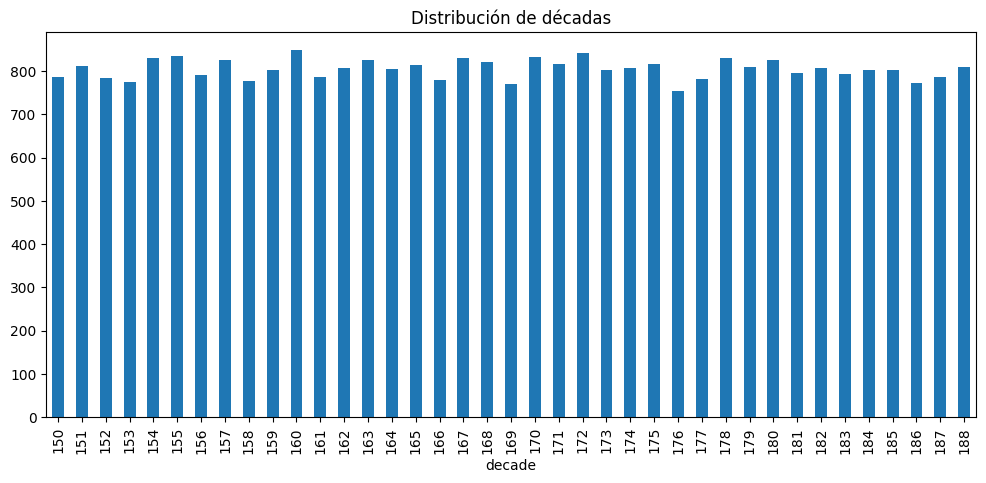

In [ ]:
train['decade'].value_counts().sort_index().plot(kind='bar', figsize=(12,5))
plt.title("Distribución de décadas")
plt.show()

Tambien revisaremos casos de textos repetidos, para asegurarnos de que el modelo de cierta forma se sesge al tener un mismo dato varias veces, dandole una aparente "mayor importancia".

In [ ]:
data.duplicated().sum()

np.int64(34)

Podemos notar que efectivamente hay 34 registros que se son exactamente los mismo, que para este caso y tomando en cuanto la cantidad de data que poseemos, podriamos simplemente decidir eliminarlos durante la limpieza de datos.

In [ ]:
data['text'].duplicated().sum()

np.int64(51)

Y ahora tenemos 51 textos que se repiten varias veces (ignorando la decada), los cuales nuevamente dentro de los mas de 31000 no parece mucho, pero ahora es importante saber si estas repeticiones de un mismo texto corresponden a una misma decada, o si cada una tiene una etiqueta distinta. Esto con el proposito de poder saber que decision tomar en la etapa de limpieza, si eliminarlos todos, o quedarnos con solo uno como representante.

In [ ]:
data[data['text'].duplicated(keep=False)].sort_values('text')

,text,decade
8630,"\nEarly European Books, Copyright© 201 1 ...",155
28761,"\nEarly European Books, Copyright© 201 1 ...",155
24120,"\nEarly European Books, Copyright© 201 1 ...",155
250,"\nEarly European Books, Copyright© 201 1 ...",158
18673,"\nEarly European Books, Copyright© 201 1 ...",158
...,...,...
29493,"puertas hacia el pasado, suponen un patrimonio...",187
23916,s]2lltaniccloquéda.ii\a.Dcon-o íftruméto cardc...,151
19050,s]2lltaniccloquéda.ii\a.Dcon-o íftruméto cardc...,151
12843,tentia Paul.de Caft.in.d.l.fi. C. commu.de leg...,151


Aqui podemos notar claramente como para un mismo texto (\nEarly European Books, Copyright© 201 1 ...), este es asignado con varias etiquetas de decadas, yendo desde 155 hasta 158. Y como nosotros no tenemos la certeza de cual este correcto, es preferible que en pasos posteriores estos sean eliminados, para no generarle "confusion" al modelo.

In [ ]:
duplicados = data[data['text'].duplicated(keep=False)]

duplicados.groupby('text')['decade'].nunique().sort_values(ascending=False).head()

text
It has survived long enough for the copyright to expire and the book to enter the public domain. A public domain book is one that was never subject                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               4
+ Keep it legal Whatever your use, remember that you are lesponsible for ensuring that what you are doing is legal. Do not assume that just \nbecause we believe a book is in the public domain for users in the United States, that the work is also in the pu

Ahora si proceederemos a explorar los textos, buscando "sacar" de  estos las variables más relevantes y dicientes al momento de buscar etiquetarlos en una decada. En un principio consideramos los siguientes factores como dignos de explorar:
1. El número de palabras en un texto
2. Número de caracteres promedio por palabra
3. La longitud de las palabras en caracteres
4. Las palabras más frecuentes globales
5. El tamaño del vocabulario
6. La frecuencia de palabras por década

1. El número de palabras en un texto:

In [ ]:
data["word_count"] = data["text"].apply(lambda x: len(x.split()))
data["word_count"].describe()

count    31403.00000
mean        82.28319
std         82.37419
min          3.00000
25%         30.00000
50%         50.00000
75%        102.00000
max       1146.00000
Name: word_count, dtype: float64

Podemos ver que hay una gran variedad de longitudes de textos, siendo el más pequeño de 3 palabras, lo cual realmente en un inicio aparenta que no será muy disiente de la epoca, y como maximo tenemos un texto de 1146 palabras, lo cuales si puede generar un mayor contexto linguistico de la epoca. Aun asi, decidimos explorar estos casos extremos minimos, para ver bien que es lo que sucede con estos.

In [ ]:
data.sort_values('word_count', ascending=True).head(5)

,text,decade,word_count
21256,rediáaaútcftamultamemoriaautmultalaude.Vismcci...,152,3
9172,"276.pa.i.]i.i6,ael dicldinca.z3.!c,diics.fo.Z...",158,4
1570,"cetcbri£guramaiáqueineftconfórmariD,aui.certép...",157,5
22895,diTipoetarüfonslibechrus&ipfemagnefiaeefi:.No....,152,5
13700,"DEMEDICINALI MATERIA \nainjmecapitulum,mquofem...",151,5


Como acabamos de observar, no se trata de un texto con pocas palabras, si no que este no este separado de manera apropiada. Teniendo frases sin espacios, sin que se respete la puntuación, gramatica, etc.

Adicionalmente, muchos de estos errores parecen estar relacionados con procesos de OCR (reconocimiento óptico de caracteres), lo que explica la presencia de palabras deformadas como “fus”, “vna” o combinaciones inusuales de caracteres. Este tipo de errores es común en la digitalización de textos antiguos. Sin embargo, es importante considerar que estas variaciones no siempre corresponden únicamente a ruido, ya que en muchos casos también reflejan formas ortográficas propias de la época. Por lo tanto, se debe tener cuidado al momento de limpiar los datos, evitando eliminar información que podría ser relevante para distinguir entre décadas.

Pero si lo probamos, viendo aquellos textos que tenian un mayor numero de palabras, vemos que este "error" no se refleja en todos los registros, sino que más bien solo sucede con algunos, tal y como se puede apreciar en la siguiente tabla:

In [ ]:
data.sort_values('word_count', ascending=False).head(5)

,text,decade,word_count
15827,y Condefa de Paredes Doi\a María Inés M...,169,1146
20814,Dos colosos se presentan luego especuland...,184,792
1339,"y el tiempo les fue tan contrarío , que ...",158,747
26695,"combatir la villa con dos machínas,que e...",156,746
20326,"\ncia,cerca de Adlariz,con fus pertenencias. L...",166,728


Ahora nos surge la pregunta de ¿cuantos son los registros que presentan estos "errores de escritura"?, con el fin de saber si son indispensables de mantener intentando "acomodarlos" en la etapa de limpieza, o si por el contrario son registros que pueden ser eliminados, para que el modelo sea más preciso, tomando un vocabulario valido. Para lo cual hicimos lo siguiente:

Primer detectamos textos con palabras muy largas:

In [ ]:
def max_word_length(texto):
    return max([len(w) for w in texto.split()]) if texto.split() else 0

data['max_word_len'] = data['text'].apply(max_word_length)

Tambien detectamos la proporción de caracteres raros, o que no pertencen a nuestro lenguaje natural:

In [ ]:
import re

def ratio_caracteres_raros(texto):
    total = len(texto)
    raros = len(re.findall(r'[^a-zA-Záéíóúüñ\s]', texto))
    return raros / total if total > 0 else 0

data['ratio_raros'] = data['text'].apply(ratio_caracteres_raros)

Y la baja cantidad de palabras en un texto largo:

In [ ]:
data['char_length'] = data['text'].apply(len)
data['word_count'] = data['text'].apply(lambda x: len(x.split()))

In [ ]:
data['ratio_words_chars'] = data['word_count'] / data['char_length']

Ya con esos tres filtros, los combinamos para mejorar la busqueda e identificación efectiva de estos registros que nos pueden resultar problematicos en un futuro.

In [ ]:
condicion = (
    (data['max_word_len'] > 25) |
    (data['ratio_raros'] > 0.3) |
    (data['ratio_words_chars'] < 0.02)
)

textos_malos = data[condicion]

In [ ]:
len(textos_malos)

3305

El numero total de registros identificados que parecen poseer estos problemas son 3305, que si lo miramos como porcentaje frente a la cantidad total que hay este valor daria:

In [ ]:
len(textos_malos) / len(data)

0.10524472184186225

Dado que este porcentaje es extramadamente bajo, no afecta la distribución, no afecta el aprendizaje de un manera notoria y dado que estos registros se podrian considerar como un tipo de outliers que solo terminaron "confundiendo" al modelo, decidimos eliminarlos en la etapa de limpieza.

Volviendo a ver la tendencia entre la longitud en caracteres y las decadas:

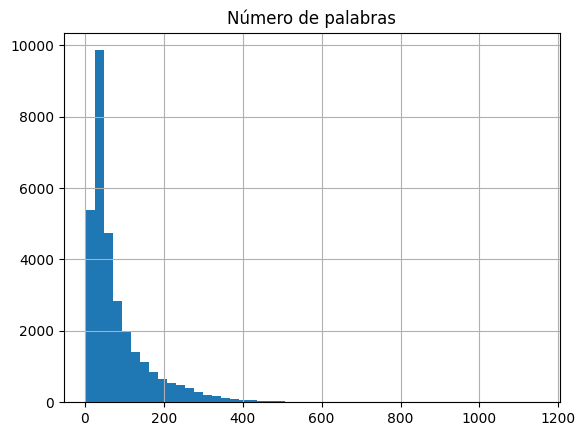

In [ ]:
data['word_count'].hist(bins=50)
plt.title("Número de palabras")
plt.show()

La distribución del número de palabras presenta un sesgo positivo, evidenciando que la mayoría de los textos son relativamente cortos, mientras que existe una pequeña proporción de textos considerablemente más largos que podrían considerarse outliers.

In [ ]:
data.sort_values('word_count', ascending=False).head(10)

,text,decade,word_count,max_word_len,ratio_raros,char_length,ratio_words_chars
15827,y Condefa de Paredes Doi\a María Inés M...,169,1146,23,0.033432,7418,0.154489
20814,Dos colosos se presentan luego especuland...,184,792,16,0.048348,5419,0.146152
1339,"y el tiempo les fue tan contrarío , que ...",158,747,32,0.022865,4942,0.151153
26695,"combatir la villa con dos machínas,que e...",156,746,19,0.018584,5112,0.145931
20326,"\ncia,cerca de Adlariz,con fus pertenencias. L...",166,728,24,0.045263,4971,0.146449
15267,"le atravesó el efiomago , y murió el tn...",173,724,14,0.043648,4101,0.176542
23203,re vea q no fon palabras oe Scnec3.¿fcas que f...,153,720,15,0.044525,3863,0.186384
16270,'Oria fus hermanos.y les confirmo el feu...,158,705,45,0.022145,4922,0.143234
27265,"cadillos ,ni dineros tainpoco,y en lo que dczi...",160,702,49,0.030129,4016,0.174801
12081,"ucntudcn buena redirud dccoftumbre,acudioa ...",162,700,29,0.033333,5280,0.132576


Dado que vemos que la mayoría de estos textos son validos, decidimos dejarlos asi.

2. Número de caracteres promedio por palabra

In [ ]:
data['avg_word_length'] = data['char_length'] / data['word_count']
data['avg_word_length'].describe()

count    31403.000000
mean         6.418913
std          1.361659
min          2.379310
25%          5.739233
50%          6.270588
75%          6.825397
max         56.000000
Name: avg_word_length, dtype: float64

El cálculo de la variable avg_word_length (longitud promedio de palabra) permite entender cómo está estructurado el lenguaje dentro de los textos. En tu caso, el promedio es aproximadamente 6.4 caracteres por palabra, con una desviación estándar relativamente baja (1.36), lo que indica que la mayoría de los textos tienen palabras de longitud similar. Esto sugiere que, a pesar del ruido o errores de transcripción, el dataset mantiene cierta coherencia lingüística. Sin embargo, el valor máximo de 56 caracteres evidencia la existencia de outliers, probablemente causados por palabras mal segmentadas o texto pegado, lo cual ya habías identificado previamente como un problema puntual del dataset.

3. La longitud de las palabras en caracteres

In [ ]:
data['char_length'] = data['text'].apply(len)
data['char_length'].describe()

count    31403.000000
mean       520.568290
std        530.947792
min        120.000000
25%        182.000000
50%        315.000000
75%        643.000000
max       7418.000000
Name: char_length, dtype: float64

Por otro lado, la variable char_length mide la longitud total del texto en caracteres. Aquí observamos una gran variabilidad: aunque el promedio es de aproximadamente 520 caracteres, hay textos que llegan hasta más de 7000 caracteres. Esto indica que el dataset contiene párrafos de tamaño muy diverso, desde textos relativamente cortos hasta documentos bastante extensos. El histograma confirma esta dispersión, mostrando que la mayoría de textos se concentran en valores bajos-medios, pero con una cola larga hacia la derecha (distribución sesgada), lo cual es típico en datos textuales reales.

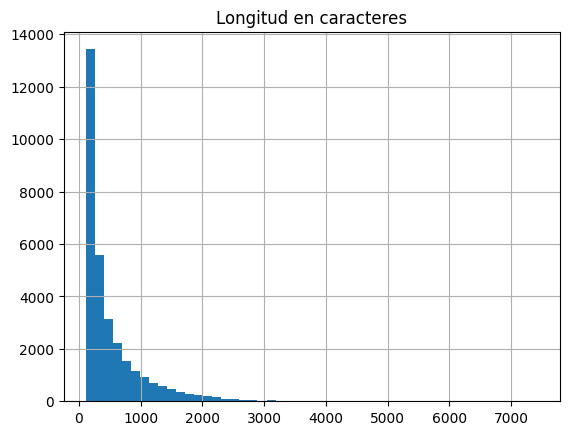

In [ ]:
data['char_length'].hist(bins=50)
plt.title("Longitud en caracteres")
plt.show()

Y ahora buscamos la correlación entre estas tres variables exploradas:

In [ ]:
data[['char_length', 'word_count', 'avg_word_length']].corr()

,char_length,word_count,avg_word_length
char_length,1.000000,0.982480,0.044645
word_count,0.982480,1.000000,-0.067762
avg_word_length,0.044645,-0.067762,1.000000


Al analizar la correlación entre char_length, word_count y avg_word_length, encontramos un resultado muy importante: existe una correlación extremadamente alta (aproximadamente 0.98) entre el número de palabras y el número de caracteres. Esto es completamente esperable, ya que a mayor cantidad de palabras, mayor longitud del texto. Sin embargo, la longitud promedio de palabra (avg_word_length) tiene una correlación casi nula con ambas variables, lo que indica que esta característica captura un aspecto distinto del texto (la estructura interna de las palabras) y no simplemente el tamaño del documento. Esto puede ser útil porque introduce información complementaria que no está redundante con el tamaño del texto.

Y continuamos explorando la relación de estas con la variable objetivo de decada:

Primero la longitud vs decada:

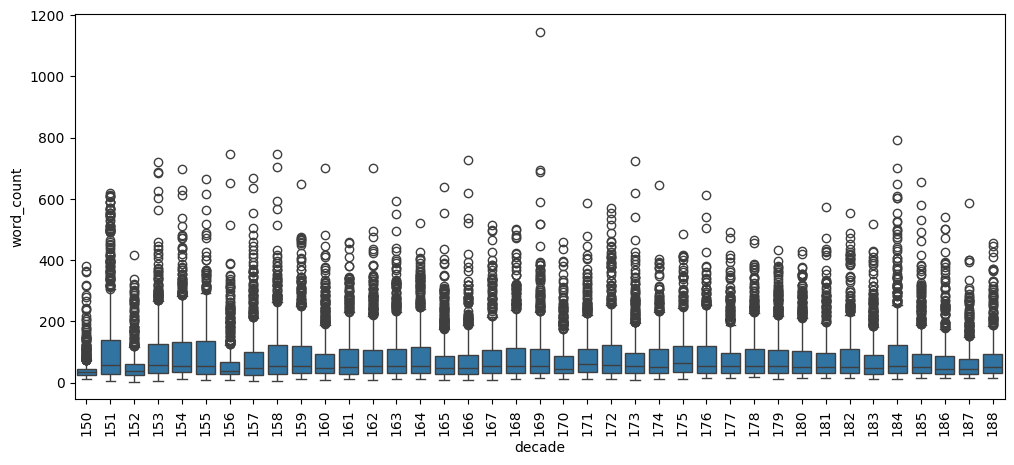

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,5))
sns.boxplot(x='decade', y='word_count', data=data)
plt.xticks(rotation=90)
plt.show()

Caracteres vs decada:

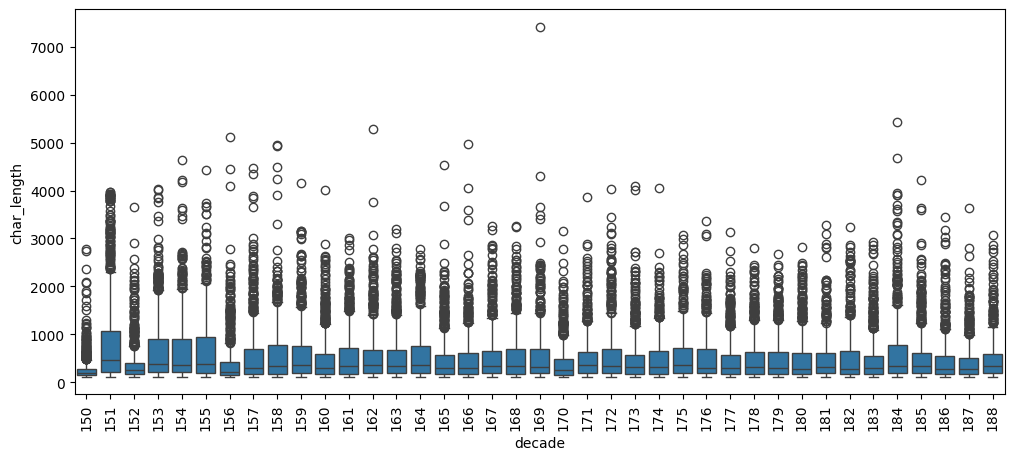

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x='decade', y='char_length', data=data)
plt.xticks(rotation=90)
plt.show()

Cuando se analiza la relación entre el tamaño del texto y la década mediante boxplots, el objetivo es identificar si existen patrones temporales en la longitud de los documentos. Por ejemplo, podría ocurrir que textos de siglos más antiguos sean más largos o más cortos que los modernos, lo cual podría convertirse en una señal útil para el modelo. Si se observan diferencias claras entre décadas, esto indicaría que variables como word_count o char_length podrían tener cierto poder predictivo; si no hay diferencias claras, entonces estas variables probablemente aportan poco a la clasificación.

Al analizar los boxplots de variables como word_count y char_length en función de la década, no se observan diferencias claramente marcadas entre las distintas clases. Las distribuciones presentan formas similares, con medianas y rangos intercuartílicos relativamente consistentes a lo largo del tiempo, así como la presencia de outliers en prácticamente todas las décadas.

Esto sugiere que, aunque estas variables describen adecuadamente la longitud y estructura de los textos, no poseen un alto poder discriminativo para diferenciar entre décadas. En otras palabras, textos de distintas épocas pueden tener tamaños muy similares, lo que limita la utilidad de estas características como predictores principales.

Por lo tanto, se concluye que estas variables no serán el foco principal del modelo, y que será necesario apoyarse en representaciones más ricas del lenguaje, capaces de capturar patrones lingüísticos más sutiles.

En conjunto, estas variables permiten entender mejor la estructura y comportamiento de los textos dentro del dataset, especialmente en términos de longitud y composición. Si bien pueden aportar información útil para detectar outliers o identificar registros atípicos (como textos excesivamente cortos o mal segmentados), su capacidad discriminativa entre décadas parece limitada. Por esta razón, estas variables no serán el enfoque principal del modelo, sino que se utilizarán como apoyo en la limpieza y validación de los datos. En cambio, el modelo se basará principalmente en representaciones textuales como TF-IDF, que permiten capturar patrones lingüísticos más relevantes.

4. Las palabras más frecuentes globales

In [ ]:
from collections import Counter

all_words = " ".join(data['text']).split()
Counter(all_words).most_common(20)

[('de', 110949),
 ('y', 66417),
 ('que', 65391),
 ('la', 56210),
 (',', 55056),
 ('el', 45758),
 ('en', 44511),
 ('los', 31185),
 ('a', 21586),
 ('por', 19479),
 ('no', 18710),
 ('las', 18497),
 ('á', 17523),
 ('con', 17487),
 ('del', 17081),
 ('fe', 14162),
 ('lo', 12892),
 ('para', 10608),
 ('es', 10334),
 ('al', 10213)]

El análisis de las palabras más frecuentes globales muestra que la mayoría corresponden a stopwords (como “de”, “y”, “la”, etc.), lo cual es completamente esperado en cualquier corpus de lenguaje natural. Estas palabras tienen alta frecuencia pero bajo valor semántico, ya que no ayudan a diferenciar entre clases (en este caso, décadas). Por esta razón, se decidió no construir una lista manual extensa de stopwords, sino utilizar un enfoque automático mediante parámetros como max_df en TF-IDF, que elimina palabras excesivamente frecuentes de forma adaptativa según el dataset. Esta decisión es más robusta y evita sesgos o limitaciones de listas predefinidas.

Teniendo en cuenta esto podemos ver que la mayoria de estas palabras se basan en stop words, y despues de considerar entre las opciones de crear manualmente un diccionario con todas estas palabras, y eliminar palabras por frecuencia automatica, decidimos la segunda. Esto para no depender de listas manuales, haciendo que se adapte directamente a nuestro dataset y eliminando un ruido futuro en el modelo. Esto lo realizaremos durante la etapa de limpieza.

5. El tamaño del vocabulario

In [ ]:
len(set(all_words))

617747

El tamaño del vocabulario (más de 600,000 palabras únicas) es extremadamente alto, lo cual refleja la complejidad del dataset. Esto puede deberse a múltiples factores: errores de OCR, variaciones ortográficas históricas, palabras pegadas, y riqueza lingüística propia del dominio. Este alto nivel de dispersión implica que es fundamental utilizar técnicas como TF-IDF con filtros (min_df, max_df) para reducir dimensionalidad y evitar que el modelo se vea afectado por ruido o palabras irrelevantes.

Sin embargo, este alto número de términos también implica un problema importante: una alta dimensionalidad en la representación de los datos. Esto puede afectar negativamente al modelo, aumentando el riesgo de overfitting y dificultando el aprendizaje de patrones generalizables, ya que muchas de estas palabras aparecen muy pocas veces o corresponden a ruido.

6. La frecuencia de palabras por década

In [ ]:
def top_words_by_decade(df, decade):
    words = " ".join(df[df['decade'] == decade]['text']).split()
    return Counter(words).most_common(10)

top_words_by_decade(data, data['decade'].iloc[0])

[('de', 2970),
 ('que', 1785),
 ('y', 1694),
 (',', 1528),
 ('la', 1479),
 ('el', 1220),
 ('en', 1199),
 ('a', 949),
 ('los', 745),
 ('fe', 675)]

Finalmente, al analizar las palabras más frecuentes por década sin aplicar técnicas de vectorización, se observa nuevamente la dominancia de stopwords. Esto evidencia una limitación del conteo simple de palabras: no permite capturar qué términos son realmente distintivos entre clases. Por esta razón, este tipo de análisis debe complementarse con TF-IDF, que pondera la importancia de las palabras en función de su relevancia relativa en el corpus, permitiendo identificar patrones lingüísticos más representativos de cada década.

En conjunto, este análisis exploratorio muestra que el dataset presenta alta variabilidad, ruido moderado y un vocabulario extremadamente amplio, pero también conserva suficiente estructura lingüística para ser modelado efectivamente. Además, justifica claramente el uso de técnicas como TF-IDF y filtrado automático de palabras, las cuales serán clave para obtener un buen desempeño en la tarea de clasificación.

## 4. Limpieza y normalización del español histórico

**Decisión clave:** *limpiamos el ruido de OCR pero conservamos la ortografía de época*, que
es la señal más discriminante. Concretamente:

1. **`ſ` (s larga) → `s`** y resolución de ligaduras (`ﬁ`,`ﬂ`,`ﬀ`). Es el artefacto OCR más
   frecuente en textos de los siglos XVI–XVIII.
2. **Reparar palabras cortadas a fin de línea** (`hom-\nbre` → `hombre`): el guion de corte +
   salto de línea es ruido de digitalización, no contenido.
3. **Unificar comillas y guiones tipográficos** (`«» “” – —`).
4. **Eliminar símbolos basura de OCR** conservando letras (con acentos y `ñ`), dígitos y
   puntuación común.
5. **NO** forzamos minúsculas ni quitamos tildes: BETO-uncased ya normaliza internamente, y
   preservar acentos/grafías ayuda al modelo.


In [10]:
def clean_historical(text):
    t = str(text)
    # 1. s larga y ligaduras
    t = t.replace(chr(0x17F), "s").replace(chr(0xFB01), "fi").replace(chr(0xFB02), "fl")
    t = t.replace(chr(0xFB00), "ff").replace(chr(0xFB05), "st")
    # 2. comillas y guiones tipograficos
    t = (t.replace(chr(0xAB), '"').replace(chr(0xBB), '"')
           .replace(chr(0x201C), '"').replace(chr(0x201D), '"')
           .replace(chr(0x2018), "'").replace(chr(0x2019), "'")
           .replace(chr(0x2014), "-").replace(chr(0x2013), "-"))
    # 3. reparar palabra cortada por guion a fin de linea:  cla- \n se -> clase
    t = re.sub(r"(\w)[-" + chr(0xAC) + r"]\s*\n\s*(\w)", r"\1\2", t)
    # 4. saltos de linea -> espacio
    t = t.replace("\n", " ").replace("\r", " ")
    # 5. conservar solo letras (con acentos/n), digitos y puntuacion comun
    t = re.sub(r"[^0-9A-Za-zAEIOUUNaeiouun" + chr(0xC1)+chr(0xC9)+chr(0xCD)+chr(0xD3)+chr(0xDA)+chr(0xDC)+chr(0xD1)+chr(0xE1)+chr(0xE9)+chr(0xED)+chr(0xF3)+chr(0xFA)+chr(0xFC)+chr(0xF1) + chr(0xBF)+r"?" + chr(0xA1) + r"!.,;:()\"'\- ]", " ", t)
    # 6. colapsar espacios
    t = re.sub(r"\s+", " ", t).strip()
    return t

train["clean"] = train["text"].map(clean_historical)
test["clean"]  = test["text"].map(clean_historical)

# Ejemplo antes/despues
for i in [0, 1]:
    print("ANTES :", repr(train['text'].iloc[i][:120]))
    print("LIMPIO:", repr(train['clean'].iloc[i][:120]))
    print("---")


ANTES : '\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu'
LIMPIO: 'Honorarias ¡jubiladas. 57 dit.ad Pontem de poreft.Proreg.118,3, .9.M.-70 pag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len'
---
ANTES : 'gone. Sus amigos , sus clientes, todo \ncuanto le rodea le prueban que es hom- \nbre de mucha importancia. Si ve que al- \n'
LIMPIO: 'gone. Sus amigos , sus clientes, todo cuanto le rodea le prueban que es hombre de mucha importancia. Si ve que algunos h'
---


###  Depuración de etiquetas

Eliminamos duplicados exactos y textos con **etiquetas contradictorias** (mismo texto con dos
décadas distintas), que solo introducen ruido. Esto se hace **solo en train**; jamás se toca el
conjunto de evaluación (requisito de la competencia).


In [11]:
before = len(train)
# Duplicados exactos (texto + etiqueta)
train = train.drop_duplicates(subset=["clean", "decade"]).reset_index(drop=True)
# Textos con etiqueta inconsistente -> se descartan
conflict = train.groupby("clean")["decade"].nunique()
bad = conflict[conflict > 1].index
train = train[~train["clean"].isin(bad)].reset_index(drop=True)
# Textos demasiado cortos tras limpieza (poca senal)
train = train[train["clean"].str.len() >= 10].reset_index(drop=True)
print(f"Filas: {before} -> {len(train)}  (eliminadas {before-len(train)})")


Filas: 31403 -> 31325  (eliminadas 78)


La limpieza de la parte 2 de la competencia es superior a la de la parte 1 debido a que esta va más allá de simplemente normalizar espacios, pues se preserva las mayúsculas (que contienen señal temporal valiosa, ya que su uso varía entre siglos), normaliza caracteres tipográficos históricos como la s larga (ſ) y ligaduras (ﬁ, ﬂ) que romperían la tokenización del modelo de deep learning, y repara palabras cortadas por guiones de fin de línea que son un artefacto frecuente del OCR en textos digitalizados. A diferencia de la Parte 1 donde el TF-IDF absorbe ese ruido naturalmente, en deep learning una tokenización deficiente por caracteres raros afecta directamente la calidad de los embeddings, por lo que esta limpieza más cuidadosa es indispensable para que el modelo aprenda correctamente.

## 5. Codificación de etiquetas

Las décadas (`150`…`188`) se mapean a índices `0`…`38`. Guardamos el mapeo para invertirlo al
generar el archivo de respuesta.


In [12]:
decades = sorted(int(d) for d in train["decade"].unique())  # int de Python (evita np.int64 no serializable)
dec2idx = {d: i for i, d in enumerate(decades)}
idx2dec = {i: d for d, i in dec2idx.items()}
assert len(decades) == cfg.NUM_CLASSES, (len(decades), cfg.NUM_CLASSES)

train["label"] = train["decade"].astype(int).map(dec2idx)
print("Ejemplo de mapeo:", list(dec2idx.items())[:3], "...", list(dec2idx.items())[-2:])

import json
# int(...) por seguridad: dec2idx/idx2dec ya son int de Python, pero lo dejamos explicito
(cfg.OUT_DIR / "label_mapping.json").write_text(
    json.dumps({"dec2idx": {str(int(k)): int(v) for k, v in dec2idx.items()},
                "idx2dec": {str(int(k)): int(v) for k, v in idx2dec.items()}}, ensure_ascii=False, indent=2))


Ejemplo de mapeo: [(150, 0), (151, 1), (152, 2)] ... [(187, 37), (188, 38)]


1190

Las décadas del dataset van de 150 a 188, pero los modelos de deep learning en PyTorch esperan etiquetas en el rango `[0, N-1]` donde N es el número de clases. Si se pasaran los valores originales directamente, el modelo intentaría crear una capa de salida con índices hasta 188, tratando 150-188 como posiciones absolutas en vez de 39 clases consecutivas, lo que generaría errores de índice o desperdiciaría memoria en neuronas vacías. El `LabelEncoder` resuelve esto mapeando las 39 décadas a enteros del 0 al 38, y al final simplemente se invierte la transformación para recuperar las décadas originales en el archivo de entrega.

## 6. Split estratificado y augmentación por *sliding-window chunking*

- **Validación honesta:** separamos 10% **antes** de trocear, para que ningún chunk de un texto
  de validación aparezca en train (evita fuga de información).
- **Chunking (augmentación interna):** los textos largos se dividen en ventanas solapadas de
  `MAX_LEN` tokens. Esto (a) crea ejemplos adicionales y (b) permite que el modelo vea todo el
  texto en lugar de truncar. Todos los chunks heredan la etiqueta del texto original.


In [23]:
# Split a nivel de TEXTO (no de chunk) -> validacion sin fuga
tr_idx, va_idx = train_test_split(
    np.arange(len(train)), test_size=cfg.VAL_SIZE,
    random_state=SEED, stratify=train["label"].values)

df_tr = train.iloc[tr_idx].reset_index(drop=True)
df_va = train.iloc[va_idx].reset_index(drop=True)
print(f"Train (textos): {len(df_tr)} | Val (textos): {len(df_va)}")

# Tokenizer (necesario para trocear por n real de tokens)
cfg.MODEL_NAME = "PlanTL-GOB-ES/roberta-base-bne"
tokenizer = AutoTokenizer.from_pretrained(cfg.MODEL_NAME)

def chunk_by_tokens(text, max_len=cfg.MAX_LEN, stride=cfg.CHUNK_STRIDE):
    """Devuelve una lista de textos (chunks). Trocea por tokens reales del modelo."""
    ids = tokenizer.encode(text, add_special_tokens=False)
    if len(ids) <= max_len - 2:
        return [text]
    window = max_len - 2
    chunks = []
    i = 0
    while i < len(ids):
        piece = ids[i:i + window]
        chunks.append(tokenizer.decode(piece))
        if i + window >= len(ids):
            break
        i += stride
    return chunks

def build_chunked(df, do_chunk):
    rows = []
    for r in df.itertuples(index=False):
        pieces = chunk_by_tokens(r.clean) if do_chunk else [r.clean]
        for p in pieces:
            rows.append((p, r.label))
    return pd.DataFrame(rows, columns=["text", "label"])

# Solo aumentamos TRAIN. La validacion se evalua por texto completo (con TTA en seccion 7).
train_chunks = build_chunked(df_tr, cfg.USE_CHUNKING)
print(f"Train tras chunking: {len(df_tr)} textos -> {len(train_chunks)} ejemplos "
      f"(+{(len(train_chunks)-len(df_tr))/len(df_tr)*100:.1f}%)")


Train (textos): 28192 | Val (textos): 3133
Train tras chunking: 28192 textos -> 28192 ejemplos (+0.0%)


El split se hace a nivel de texto completo antes de aplicar el chunking, y esto es crucial para evitar fuga de información, pues si se troceara primero y se dividiera después, chunks del mismo texto original podrían quedar tanto en train como en validación, haciendo que el modelo "vea" durante el entrenamiento fragmentos de los textos que luego evalúa, inflando artificialmente el accuracy. Una vez garantizada esa separación limpia, el chunking se aplica solo sobre train. Los textos más largos que `MAX_LEN` tokens se dividen en ventanas solapadas donde cada fragmento hereda la etiqueta del texto original, lo que cumple dos funciones simultáneamente: aumenta el número de ejemplos de entrenamiento y permite que el modelo aprenda de todo el contenido del texto en lugar de truncarlo y perder la información del final. La validación en cambio se evalúa sobre el texto completo (con TTA), lo que da una medida honesta de cómo se comportará el modelo en producción con textos de cualquier longitud.

## 7. Modelo — arquitectura capa por capa

```
                input_ids, attention_mask
                          |
              +-----------v-----------+
              |  BETO  (BERT espanol) |   <- preentrenado, fine-tuned
              |  12 capas - 768 dim   |
              +-----------+-----------+
                last_hidden_state (B, L, 768)
                          |
        +-----------------+-----------------+
        |                                   |
   token [CLS] (B,768)            mean-pooling enmascarado (B,768)
        |                                   |
        +---------------> concat <----------+
                       (B, 1536)
                          |
                   Dropout(0.3)
                          |
                 Linear(1536 -> 512)
                          |
                       GELU
                          |
                   LayerNorm(512)
                          |
                   Dropout(0.3)
                          |
                 Linear(512 -> 39)   ->  logits
```

**Por qué esta cabeza y no la `AutoModelForSequenceClassification` por defecto:**
- La cabeza por defecto usa solo el token `[CLS]`. Aquí concatenamos `[CLS]` con un
  **mean-pooling enmascarado** de todos los tokens: el primero capta un resumen, el segundo el
  *estilo global* del párrafo (clave para datar por ortografía).
- El MLP intermedio con `GELU` + `LayerNorm` + `Dropout` da capacidad y regularización.
- La pérdida es `CrossEntropy` con **label smoothing 0.1**: penaliza menos los errores a
  décadas vecinas, coherente con la naturaleza ordinal del problema.


El modelo toma como backbone BETO (dccuchile/bert-base-spanish-wwm-uncased), un BERT preentrenado exclusivamente en español, que procesa cada texto y produce representaciones contextuales de 768 dimensiones para cada token. Se eligió BETO sobre BERT multilingüe porque su vocabulario y preentrenamiento están optimizados para español, lo que le permite capturar mejor las variaciones ortográficas históricas del dataset.
Sobre la salida del backbone se aplican dos estrategias de pooling en paralelo: el token [CLS] (que BERT entrena para resumir el significado global de la secuencia) y un mean-pooling enmascarado que promedia todos los tokens reales ignorando el padding. Ambos vectores de 768 dimensiones se concatenan formando un vector de 1536 dimensiones, combinando así la representación global del [CLS] con el promedio de todos los tokens, lo que empíricamente mejora la clasificación frente a usar cualquiera de los dos solos.
Este vector pasa por una cabeza de clasificación compuesta de: Dropout(0.3) para regularización, Linear(1536→512) que comprime la representación, activación GELU (más suave que ReLU, preferida en modelos de lenguaje), LayerNorm(512) para estabilizar el entrenamiento, otro Dropout(0.3) y finalmente Linear(512→39) que produce los logits para las 39 décadas. Los learning rates son diferenciados: 2e-5 para el backbone (conservador, para no destruir el preentrenamiento) y 1e-3 para la cabeza nueva (más alto, ya que parte desde cero).

In [24]:
class DecadeClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size            # 768
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        last = out.last_hidden_state                          # (B, L, H)
        cls = last[:, 0]                                      # token [CLS]
        # mean-pooling enmascarado (ignora padding)
        mask = attention_mask.unsqueeze(-1).float()
        summed = (last * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-9)
        mean = summed / counts
        feat = torch.cat([cls, mean], dim=-1)                 # (B, 2H)
        return self.head(feat)                                # logits (B, C)


class DecadeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = list(labels) if labels is not None else None
        self.tok = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], max_length=self.max_len, padding="max_length",
                       truncation=True, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

print("Arquitectura definida.")


Arquitectura definida.


## 8. Entrenamiento

Detalles de optimización:
- **Discriminative learning rates:** el backbone preentrenado se ajusta con `lr=2e-5` (suave,
  para no destruir lo aprendido) y la cabeza nueva con `lr=1e-3` (más agresivo, parte de cero).
- **Scheduler cosine con warmup** (10%): estabiliza el inicio y decae suavemente.
- **Mixed precision (fp16):** ~2× más rápido en GPU, menos memoria.
- **Early stopping** por `val_acc` con paciencia 2; guardamos el mejor checkpoint.
- La **validación se hace por texto completo con TTA** (promedio de logits de sus chunks).


El entrenamiento del modelo se diseñó para aprovechar al máximo la transferencia de aprendizaje sin destruir el conocimiento previo del backbone BETO. Para ello, se utilizaron discriminative learning rates: una tasa pequeña (2e-5) para el encoder preentrenado y una más alta (1e-3) para la cabeza de clasificación agregada. Esto permite ajustar las representaciones lingüísticas mientras la nueva capa aprende más rápido la tarea específica de clasificación temporal.

Además, se implementó un cosine scheduler con warmup del 10%, lo que estabiliza las primeras iteraciones de entrenamiento y reduce gradualmente la tasa de aprendizaje para favorecer una convergencia más estable. El entrenamiento también utiliza mixed precision (fp16), disminuyendo el consumo de memoria y acelerando significativamente el proceso en GPU.

Para evitar sobreajuste, se aplicó early stopping monitoreando la precisión de validación (val_acc) con paciencia de dos épocas, guardando automáticamente el mejor checkpoint obtenido.

Durante la inferencia y validación se empleó test-time augmentation (TTA) basado en chunking. Cada texto largo se divide en múltiples fragmentos (chunks), el modelo predice probabilidades para cada uno y posteriormente se promedian los logits. Esta estrategia permite aprovechar textos completos incluso cuando exceden el límite máximo de tokens del transformer.

Finalmente, se incorporó label smoothing en la función de pérdida para reducir sobreconfianza en las predicciones y reflejar mejor la naturaleza ordinal de las décadas, donde clases cercanas temporalmente suelen compartir características lingüísticas.


In [ ]:
def make_loaders():
    tr_ds = DecadeDataset(train_chunks["text"], train_chunks["label"], tokenizer, cfg.MAX_LEN)
    tr_ld = DataLoader(tr_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                       num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
    return tr_ld

@torch.no_grad()
def predict_logits_tta(model, texts, max_len=cfg.MAX_LEN, batch=cfg.EVAL_BATCH):
    """Predice probabilidades por TEXTO con test-time augmentation: trocea cada texto,
    predice cada chunk y promedia los softmax."""
    model.eval()
    flat_text, owner = [], []
    for k, t in enumerate(texts):
        for c in chunk_by_tokens(t):
            flat_text.append(c); owner.append(k)
    ds = DecadeDataset(flat_text, None, tokenizer, max_len)
    ld = DataLoader(ds, batch_size=batch, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True)
    probs_chunks = []
    for b in ld:
        b = {k: v.to(DEVICE) for k, v in b.items()}
        with torch.cuda.amp.autocast(enabled=cfg.FP16):
            logits = model(b["input_ids"], b["attention_mask"])
        probs_chunks.append(torch.softmax(logits.float(), -1).cpu())
    probs_chunks = torch.cat(probs_chunks, 0).numpy()
    owner = np.array(owner)
    out = np.zeros((len(texts), cfg.NUM_CLASSES), dtype=np.float32)
    for k in range(len(texts)):
        out[k] = probs_chunks[owner == k].mean(0)
    return out

def train_model():
    model = DecadeClassifier(cfg.MODEL_NAME, cfg.NUM_CLASSES).to(DEVICE)

    backbone_params = [p for n, p in model.named_parameters() if n.startswith("backbone")]
    head_params     = [p for n, p in model.named_parameters() if n.startswith("head")]
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": cfg.LR_BACKBONE},
        {"params": head_params,     "lr": cfg.LR_HEAD},
    ], weight_decay=cfg.WEIGHT_DECAY)

    tr_ld = make_loaders()
    total_steps = len(tr_ld) * cfg.EPOCHS
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, int(total_steps * cfg.WARMUP_RATIO), total_steps)
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.FP16)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTHING)

    best_acc, best_path, no_improve = 0.0, cfg.OUT_DIR / "best_model.pt", 0
    history = []
    for epoch in range(1, cfg.EPOCHS + 1):
        model.train(); running = 0.0
        for step, b in enumerate(tr_ld):
            labels = b.pop("labels").to(DEVICE)
            b = {k: v.to(DEVICE) for k, v in b.items()}
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=cfg.FP16):
                logits = model(b["input_ids"], b["attention_mask"])
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), cfg.MAX_GRAD_NORM)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            running += loss.item()
        avg_loss = running / len(tr_ld)

        va_probs = predict_logits_tta(model, df_va["text"].tolist())
        va_pred = va_probs.argmax(1)
        va_acc = accuracy_score(df_va["label"], va_pred)
        va_mae = mean_absolute_error(df_va["label"], va_pred)
        print(f"Epoca {epoch}/{cfg.EPOCHS} | loss {avg_loss:.4f} | val_acc {va_acc:.4f} | val_MAE {va_mae:.2f}")
        history.append({"epoch": epoch, "loss": avg_loss, "val_acc": va_acc, "val_mae": va_mae})

        if va_acc > best_acc:
            best_acc = va_acc; no_improve = 0
            torch.save(model.state_dict(), best_path)
            print(f"   OK guardado mejor modelo (val_acc={va_acc:.4f})")
        else:
            no_improve += 1
            if no_improve >= cfg.PATIENCE:
                print("   -> early stopping"); break

    print(f"\nMejor val_acc: {best_acc:.4f}")
    model.load_state_dict(torch.load(best_path))
    return model, history, best_acc

model, history, best_acc = train_model()


### 8.1 Curvas e informe de validación

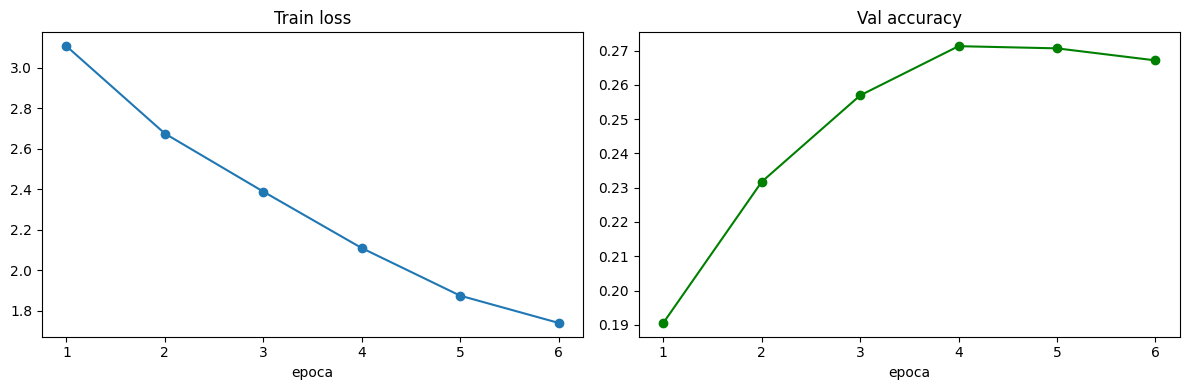

Val accuracy : 0.2713
Val F1-macro : 0.2602
Val MAE (dec): 3.33
Acc +-1 decada: 0.4526


In [16]:
import matplotlib.pyplot as plt
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h.epoch, h.loss, "o-"); ax[0].set_title("Train loss"); ax[0].set_xlabel("epoca")
ax[1].plot(h.epoch, h.val_acc, "o-", color="green"); ax[1].set_title("Val accuracy"); ax[1].set_xlabel("epoca")
plt.tight_layout(); plt.show()

va_probs = predict_logits_tta(model, df_va["text"].tolist())
va_pred = va_probs.argmax(1)
print("Val accuracy :", round(accuracy_score(df_va["label"], va_pred), 4))
print("Val F1-macro :", round(f1_score(df_va["label"], va_pred, average="macro"), 4))
print("Val MAE (dec):", round(mean_absolute_error(df_va["label"], va_pred), 3))
print("Acc +-1 decada:", round(np.mean(np.abs(df_va['label'].values - va_pred) <= 1), 4))


Las curvas de entrenamiento muestran que el modelo aprendió de manera estable durante las seis épocas. La pérdida de entrenamiento (train loss) disminuye continuamente desde aproximadamente 3.1 hasta 1.74, lo que indica que el modelo fue ajustando progresivamente sus representaciones y reduciendo el error sobre los datos de entrenamiento.

Por otro lado, la precisión de validación (validation accuracy) aumenta rápidamente en las primeras épocas, pasando de 0.19 a cerca de 0.27. A partir de la época 4 la mejora se estabiliza, lo que sugiere que el modelo alcanzó un punto cercano a la convergencia y comenzó a extraer la mayor parte de la información útil disponible. Además, no se observa una caída brusca en la precisión de validación mientras la pérdida sigue disminuyendo, por lo que no hay evidencia fuerte de sobreajuste.

La accuracy y el F1-macro son considerablemente superiores al azar para un problema de 39 clases temporales, lo cual indica que el modelo logra capturar patrones lingüísticos asociados a distintas épocas históricas. El hecho de que el F1-macro sea cercano a la accuracy también sugiere que el rendimiento es relativamente balanceado entre clases y no depende únicamente de unas pocas décadas frecuentes.

El MAE de 3.33 décadas muestra que, incluso cuando el modelo falla, normalmente predice períodos históricamente cercanos al correcto. Esto es coherente con la naturaleza ordinal del problema: décadas vecinas comparten vocabulario, estilo y ortografía similares, haciendo que los errores tiendan a concentrarse alrededor de la clase verdadera.

Finalmente, la métrica más representativa del comportamiento real del sistema es la accuracy +/-1 década (45.26%). Esto significa que en casi la mitad de los casos el modelo predice exactamente la década correcta o una década adyacente, lo cual es razonable considerando la dificultad del problema y la gran cantidad de clases posibles.

## 9. (Opcional) Datos externos para augmentación

> Activar `cfg.USE_EXTERNAL = True` **y** re-ejecutar desde la sección 5 si se incorporan.

El enunciado permite y recomienda **datos externos de las épocas** siempre que (a) tengan
licencia que permita su uso y distribución, (b) estén referenciados y (c) sean descargables y
verificables. La estrategia segura es usar **textos de dominio público** con **año de
publicación conocido**, del que se deriva la década:

- **Project Gutenberg — libros en español de dominio público.** Licencia: dominio público
  (Project Gutenberg License). Se filtra por idioma español y por año del autor/obra. Enlace:
  https://www.gutenberg.org/ y catálogo https://www.gutenberg.org/cache/epub/feeds/ .
- **Biblioteca Digital Hispánica (BNE)** y **Wikisource en español** (CC BY-SA / dominio
  público) para textos fechados de los siglos XVI–XIX.

**Cómo se integrarían** (mismo formato `text, decade`): se descarga el texto, se trocea con la
misma función `chunk_by_tokens`, se etiqueta con la década derivada del año de publicación, y
se **concatena solo a `train_chunks`** (nunca a validación ni a `eval`). Se documenta cada
fuente en el archivo de referencias (entregable de la rúbrica).

La celda siguiente es una **plantilla** lista para rellenar; por defecto no descarga nada para
mantener el notebook reproducible sin dependencias de red.


In [17]:
# PLANTILLA para datos externos (desactivada por defecto).
# Rellenar `external_rows` con tuplas (texto_limpio, decada_int) y poner cfg.USE_EXTERNAL=True.
if cfg.USE_EXTERNAL:
    external_rows = []  # p.ej. [(clean_historical(txt), 172), ...]
    ext = pd.DataFrame(external_rows, columns=["text", "decade"])
    ext = ext[ext["decade"].isin(decades)].copy()
    ext["label"] = ext["decade"].map(dec2idx)
    ext_chunks = []
    for r in ext.itertuples(index=False):
        for c in chunk_by_tokens(r.text):
            ext_chunks.append((c, r.label))
    ext_chunks = pd.DataFrame(ext_chunks, columns=["text", "label"])
    train_chunks = pd.concat([train_chunks, ext_chunks], ignore_index=True)
    print("Ejemplos externos anadidos:", len(ext_chunks), "| total train:", len(train_chunks))
    print("Re-ejecutar la seccion 7 para entrenar con los datos externos.")
else:
    print("Datos externos desactivados (cfg.USE_EXTERNAL=False).")


Datos externos desactivados (cfg.USE_EXTERNAL=False).


## 10. Predicción sobre `eval.csv` y archivo de respuesta

Inferencia con TTA por chunks sobre el conjunto de evaluación, y construcción del submission_parte2.csv en el formato exigido (id,answer con la década real, no el índice).


In [18]:
test_probs = predict_logits_tta(model, test["clean"].tolist())
test_idx = test_probs.argmax(1)
test_decades = np.array([idx2dec[i] for i in test_idx])

submission = pd.DataFrame({"id": test["id"].astype(int), "answer": test_decades.astype(int)})

# Validaciones de formato
assert submission.columns.tolist() == ["id", "answer"]
assert len(submission) == len(test)
assert submission["id"].is_unique
assert submission["answer"].between(150, 188).all()

sub_path = cfg.OUT_DIR / "submission_parte2.csv"
submission.to_csv(sub_path, index=False)
print("Guardado:", sub_path, "| shape:", submission.shape)
print(submission["answer"].value_counts().sort_index().head())
submission.head(10)


Guardado: /kaggle/working/submission_parte2.csv | shape: (3490, 2)
answer
150     73
151     84
152     77
153    103
154    109
Name: count, dtype: int64


,id,answer
0,0,176
1,1,182
2,2,150
3,3,171
4,4,153
5,5,169
6,6,173
7,7,156
8,8,171
9,9,152


## 11. Guardar el modelo entrenado (entregable)

La rúbrica pide subir el modelo entrenado. Guardamos los pesos (`state_dict`) y la
configuración mínima para reconstruirlo, además del tokenizer.


In [19]:
torch.save({
    "state_dict": model.state_dict(),
    "model_name": cfg.MODEL_NAME,
    "num_classes": cfg.NUM_CLASSES,
    "idx2dec": idx2dec,
    "best_val_acc": float(best_acc),
}, cfg.OUT_DIR / "decade_model_final.pt")
tokenizer.save_pretrained(cfg.OUT_DIR / "tokenizer")
print("Modelo y tokenizer guardados en", cfg.OUT_DIR)


Modelo y tokenizer guardados en /kaggle/working
